# K-Means — perfil climático por região

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/Coffee_Data_Set.csv")
partes = df["Location"].str.split("_")
df["pais"] = partes.str[0]
df["regiao"] = partes.str[1:].str.join(" ")
df["temperatura_media"] = (df["Temp_Max"] + df["Temp_Min"]) / 2
df = df.rename(columns={
    "Precipitation_mm": "precipitacao",
    "Humidity": "umidade",
    "Solar_Radiation": "radiacao_solar",
})

colunas = ["temperatura_media", "precipitacao", "umidade", "radiacao_solar"]
perfis = df.groupby(["pais", "regiao"], as_index=False)[colunas].mean()
perfis

,pais,regiao,temperatura_media,precipitacao,umidade,radiacao_solar
0,Brazil,Espirito Santo Afonso,22.758541,2.979250,77.425737,17.566441
1,Brazil,Espirito Santo Conceicao,22.169075,3.148545,78.749172,17.464283
2,Brazil,Minas Gerais Aqua Boa,23.152938,2.711495,71.376330,18.069560
3,Brazil,Minas Gerais Manhuacu,21.729783,3.357127,71.864791,18.666445
4,Brazil,Minas Gerais Patrocinio,21.873539,3.332626,71.223442,19.328008
5,Brazil,Minas Gerais Varginha,21.286519,3.370547,73.900008,18.426936
6,Brazil,Sao Paulo Campinas,21.338881,3.437258,75.749688,18.524696
7,Brazil,Sao Paulo Sao Jose,22.886925,3.665230,69.512648,19.073169
8,China,Puer,19.591259,4.286512,80.563735,16.496470
9,Colombia,Andes,18.354262,6.317454,87.449386,17.183164


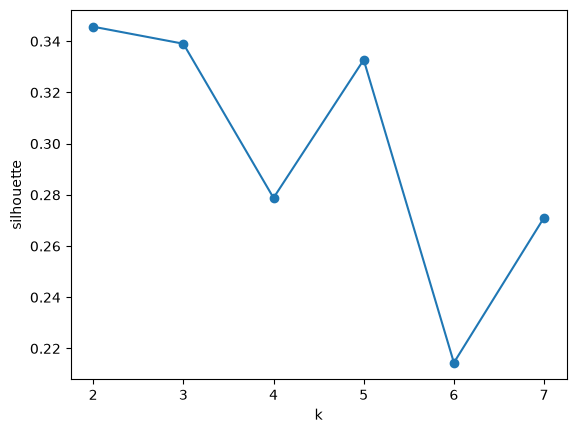

In [2]:
X = StandardScaler().fit_transform(perfis[colunas])

inercias, silhuetas = [], []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X, km.labels_))

plt.plot(range(2, 8), silhuetas, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.show()

In [3]:
melhor_k = list(range(2, 8))[silhuetas.index(max(silhuetas))]
modelo = KMeans(n_clusters=melhor_k, random_state=42, n_init=10).fit(X)
perfis["cluster"] = modelo.labels_
perfis.sort_values("cluster")

,pais,regiao,temperatura_media,precipitacao,umidade,radiacao_solar,cluster
11,Colombia,Santuario,22.044348,7.781380,89.053685,17.177208,0
10,Colombia,Morelia,23.269165,4.193702,85.637443,15.742592,0
14,Ethiopia,Aleto2,19.281872,4.422011,78.547851,18.852790,0
12,Colombia,Timbio,19.533641,2.881647,82.229374,14.717255,0
9,Colombia,Andes,18.354262,6.317454,87.449386,17.183164,0
8,China,Puer,19.591259,4.286512,80.563735,16.496470,0
19,Guatemala,San Marcos,19.301876,5.855763,83.276929,18.922589,0
17,Guatemala,Huehuetenango,17.854283,4.853518,80.128082,18.644973,0
7,Brazil,Sao Paulo Sao Jose,22.886925,3.665230,69.512648,19.073169,1
6,Brazil,Sao Paulo Campinas,21.338881,3.437258,75.749688,18.524696,1
